![Financial Risk & Loan Approval](https://images.unsplash.com/photo-1601597111158-2fceff292cdc?w=1200&q=50)


# Predicting Loan Default Risk at FinTech Innovations
### A Machine Learning Approach to Credit Decision Automation

## Overview

FinTech Innovations processes thousands of loan applications through a manual review system that is slow, inconsistent, and prone to human bias. This project builds a supervised classification model trained on 20,000 historical applications ,spanning applicant demographics, credit history, income, assets, and behavioral signals ,to predict whether a loan should be approved and assign a risk score to each applicant.

Given the asymmetric cost structure of this problem ($50,000 average loss on a defaulted loan vs. $8,000 profit foregone on a wrongly denied application), minimizing false approvals is the priority without aggressively excluding creditworthy applicants. The final model achieved an F1 score of 0.921 and ROC-AUC of 0.993 on held-out test data, delivering an estimated Net Business Value of $3,190,000 compared to a $0 baseline. The pipeline is designed to assist loan officers rather than fully replace them, providing interpretable risk scores that support faster, more consistent decisions.

## Business Understanding

### 1. Business Context Analysis
**Current Process & Limitations**<br>
FinTech Innovations currently relies on manual review by loan officers to approve or deny applications. This process has several critical limitations:
- **Inconsistency**: Different officers apply different standards, leading to subjective and variable decisions across similar applicants.
- **Speed**: Manual review creates bottlenecks, slowing response times and potentially losing applicants to competitors.
- **Scalability**: Human review cannot efficiently scale with growing application volumes.
- **Hidden bias**: Officers may unconsciously favor or penalize applicants based on non-financial signals.
- **Missed opportunities**: Creditworthy applicants with unconventional profiles may be denied due to over-reliance on traditional criteria.

**Key Stakeholders & Their Needs**

| Stakeholder | Need |
|---|---|
| Loan Officers | A reliable decision-support tool — not a black box replacement |
| Risk Management | Minimise defaults and financial exposure |
| Applicants | Fair, fast, consistent decisions |
| Regulators | Transparent, explainable, bias-free decisions |
| FinTech Leadership | Profitability, scalability, and competitive edge |

**Model Error Implications**

The cost structure of this problem is **asymmetric**; not all errors are equal:

- **False Positive (approving a bad loan):** The applicant defaults. Average loss = **$50,000** (principal + collection costs). This is the most costly error.
- **False Negative (denying a good loan):** A creditworthy applicant is rejected. Average profit foregone = **$8,000**. Still costly, but 6.25× less damaging than a false positive.

This asymmetry means we must prioritise precision on the positive (approved) class and be willing to accept some false negatives to avoid catastrophic defaults.


**Classification vs. Regression**

This project uses a **classification approach** (predicting `LoanApproved`: 0 or 1) as the primary task. Although `RiskScore` appears in the dataset, it will be excluded from modeling as it is derived from the target variable and would cause data leakage.

Justification:
- The business decision is binary : approve or deny. A classification output maps directly to an actionable decision.
- The `LoanApproved` label is already present in the data and reflects real historical decisions.
- Classification models produce calibrated probabilities that double as risk scores for loan officers.
- Regression on `RiskScore` alone would require a secondary thresholding step, adding complexity without clear benefit for the primary use case.



### 2. Modeling Goals & Success Criteria

**Evaluation Metrics**

Standard accuracy is insufficient given the cost asymmetry — a model that approves everyone scores well on accuracy but is financially disastrous. We use:

**Primary Metric — F1 Score:**
Balances precision and recall equally. Since both false approvals ($50,000 loss) and false denials ($8,000 foregone profit) carry real costs, F1 captures this tradeoff without over-weighting either direction.

**Secondary Metric — ROC-AUC:**
Measures the model's ability to rank good vs. bad loans across all thresholds. Useful for comparing models independent of any single decision cutoff.

**Custom Metric — Net Business Value (NBV):**
Translates predictions directly into dollar impact:

- True Positive (correctly approved): **+$8,000**
- False Positive (approved a defaulter): **−$50,000**
- False Negative (denied a good applicant): **−$8,000**
- True Negative (correctly denied): **$0**

**Baseline Targets**

| Metric | Baseline | Target |
|---|---|---|
| F1 Score | ~0.00 | ≥ 0.65 |
| ROC-AUC | 0.50 | ≥ 0.80 |
| Net Business Value | Negative | Positive |


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [148]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import randint, uniform
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay




In [149]:
# EDA Code Here - Create New Cells As Needed
df=pd.read_csv("financial_loan_data.csv")

In [150]:
# Check shape of data
print(f"The data has {df.shape[0]} Rows and {df.shape[1]} columns")

# Check the columns
print(f" \n The data has columns\n{df.columns}")

# Check on the first 5 rows and last 5 rows
print("\n----First five------")
print(df.head())

print("\n----Last five------")
print(df.tail())

The data has 20000 Rows and 35 columns
 
 The data has columns
Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='object')

----First five------
   Age AnnualIncome  CreditScore EmploymentStatus EducationLevel  Experience  \
0   45   $39,948.00          617         Empl

In [151]:
# Basic infomation on columns and thier data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [152]:
# Basic numercal statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [153]:
# Check for duplicates
df.duplicated().sum()

0

In [154]:
# Check on missing values
df.isna().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [155]:
# Removing $ from AnnualIncome and changing the data type to float
df['AnnualIncome']= df['AnnualIncome'].replace('[$,]', '', regex= True).astype('float')


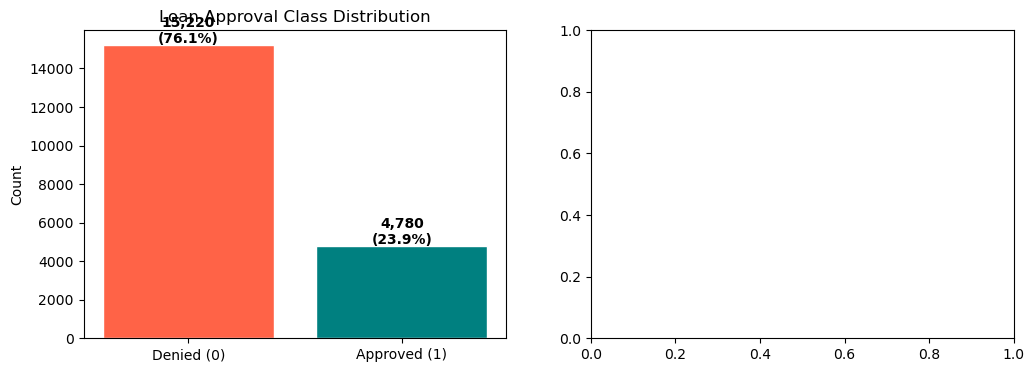

In [156]:
# Class Imbalance Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


counts = df['LoanApproved'].value_counts()
axes[0].bar(['Denied (0)', 'Approved (1)'], counts.values, color=['tomato', 'teal'], edgecolor='white')
axes[0].set_title('Loan Approval Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')



In [157]:
print(df['LoanApproved'].value_counts())
print(df['LoanApproved'].value_counts(normalize= True).round(3))

LoanApproved
0    15220
1     4780
Name: count, dtype: int64
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


##### Target Distribution
The dataset is heavily imbalanced — 76.1% of applications were denied (15,220) and only 23.9% approved (4,780). 
This imbalance means a naive model that denies everyone would achieve 76% accuracy, making accuracy a misleading 
metric. We will address this using `class_weight='balanced'` during modeling.

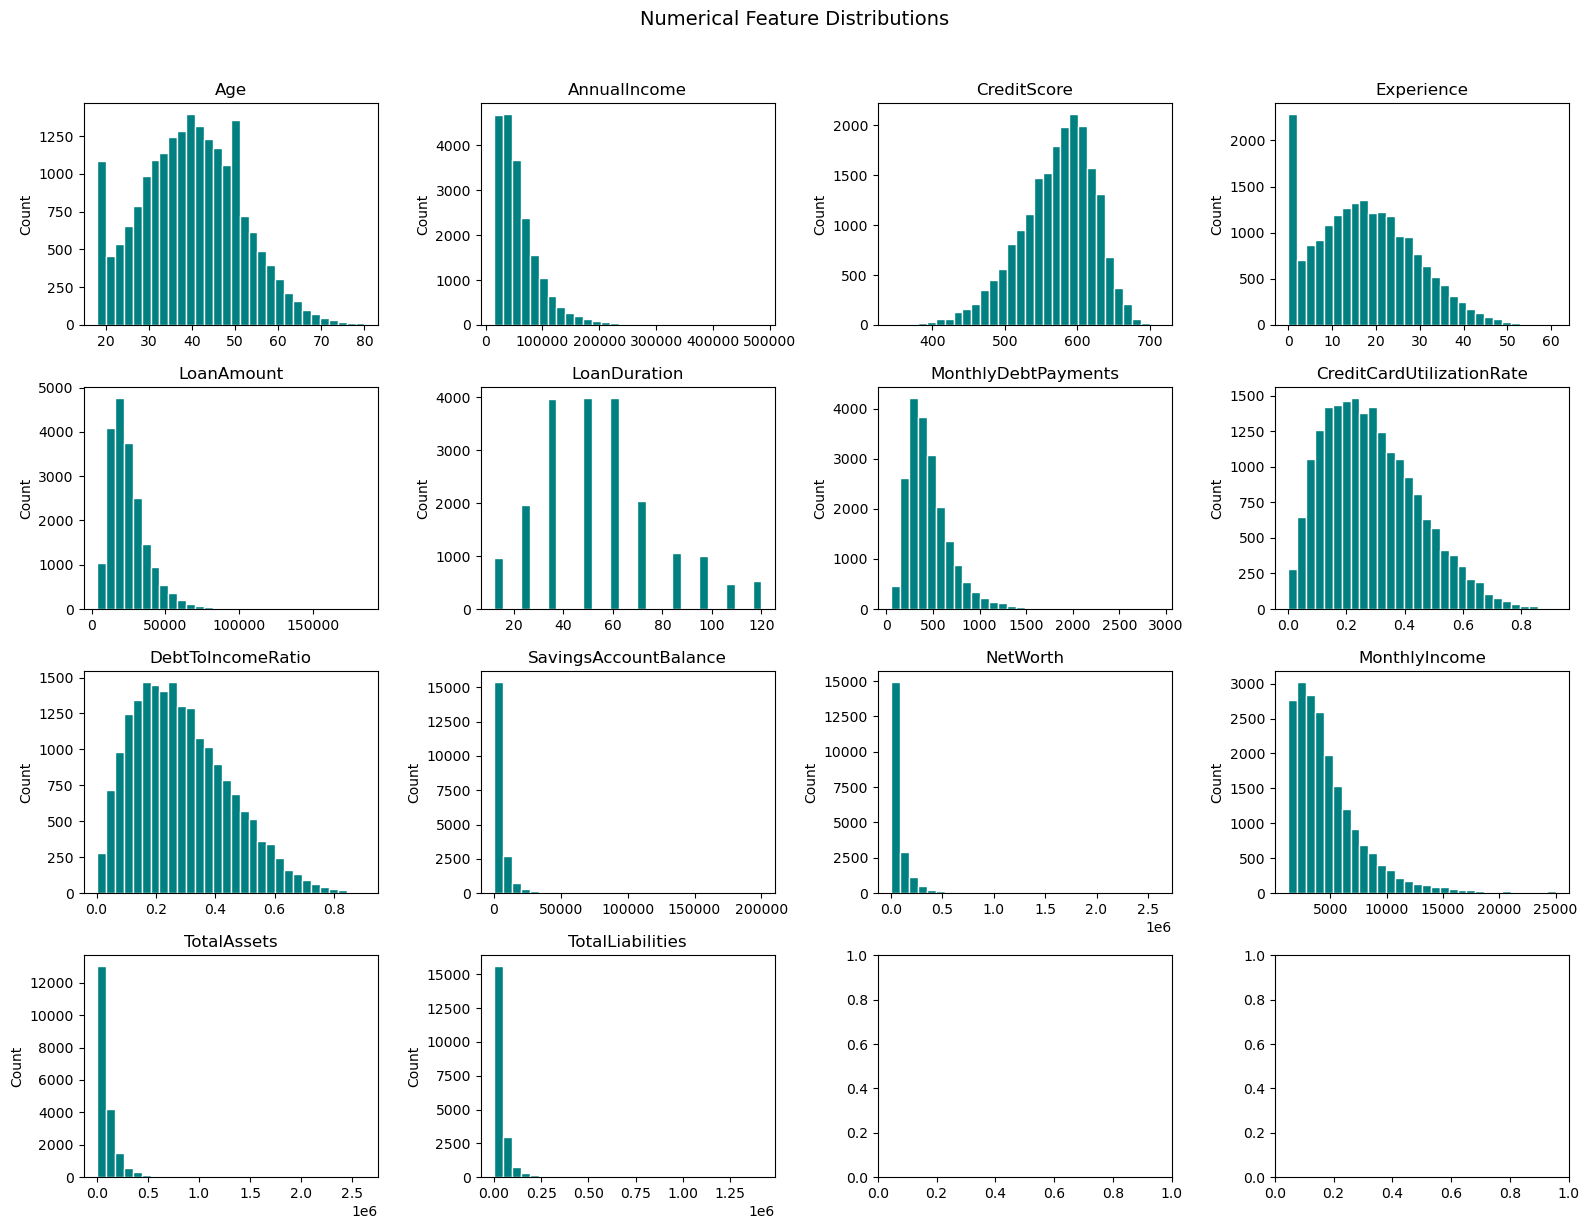

In [158]:
# Numerical Feature Distribution
num_cols = ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 
            'LoanDuration', 'MonthlyDebtPayments', 'CreditCardUtilizationRate',
            'DebtToIncomeRatio', 'SavingsAccountBalance', 'NetWorth', 
            'MonthlyIncome', 'TotalAssets', 'TotalLiabilities']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="teal", edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##### Numerical Feature Distributions

Most numerical features are right-skewed, particularly `AnnualIncome`, `SavingsAccountBalance`, 
`NetWorth`, `TotalAssets`, and `TotalLiabilities`, a small number of applicants hold 
significantly more wealth than the majority. This confirms that `RobustScaler` is the 
appropriate scaling choice, as it is not distorted by extreme values.

`CreditScore` follows an approximately normal distribution centered around 580–620, 
while `Age` and `Experience` show slight right skew with most applicants in the 
20–50 and 0–20 year ranges respectively.

`LoanDuration` shows a discrete distribution with clear spikes at round numbers 
(12, 24, 36, 60 months), which is expected for a loan product with fixed term options.

`CreditCardUtilizationRate` and `DebtToIncomeRatio` are concentrated at lower values 
but trail off to the right, suggesting most applicants maintain moderate debt levels 
with a minority of high-risk outliers.

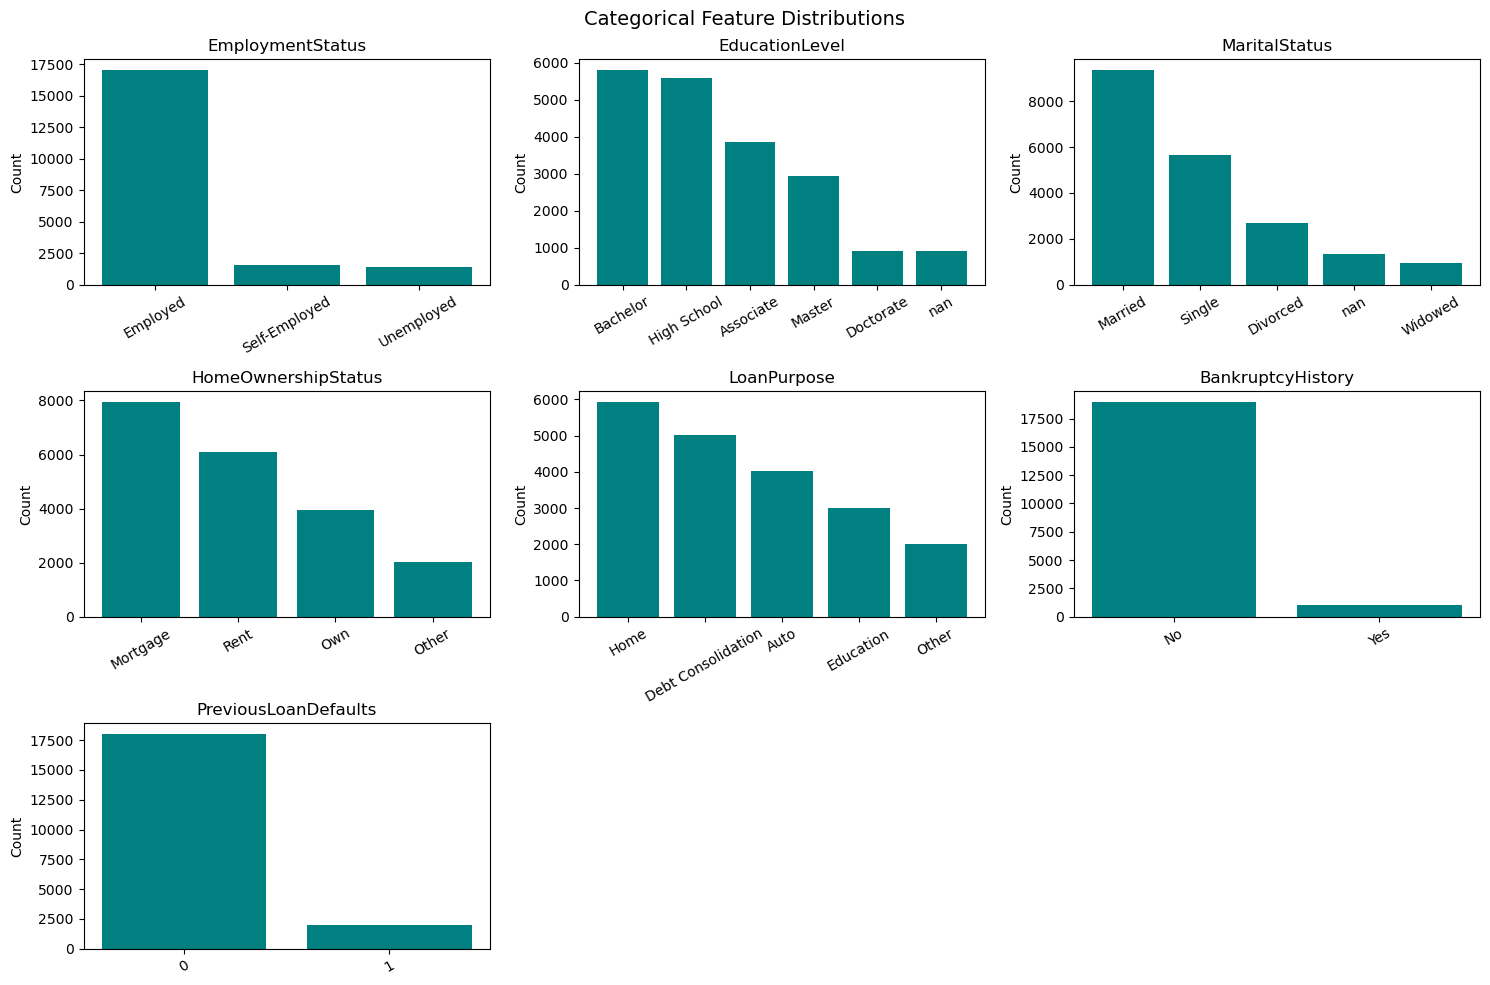

In [159]:
# Categorical Feature Distributions
cat_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 
            'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory', 
            'PreviousLoanDefaults']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].astype(str).value_counts()
    axes[i].bar(counts.index, counts.values, color='teal')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

# Hide empty subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

##### Categorical Feature Distributions
The majority of applicants are Employed , with very few Unemployed. Education levels are fairly balanced  across Bachelor, High School, and Associate degrees. Bankruptcy history is rare , and most applicants have no previous loan defaults.

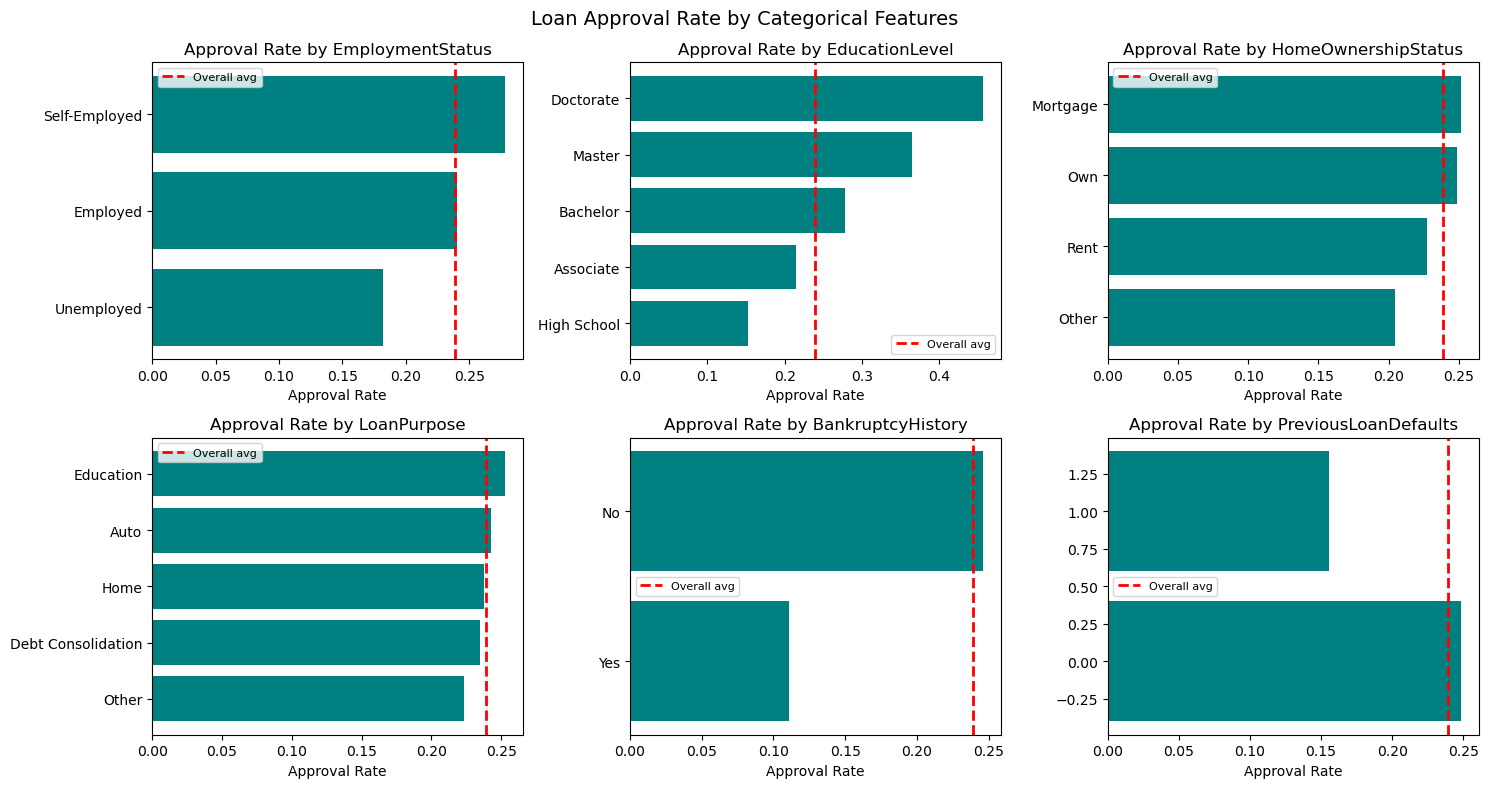

In [160]:
# Approval Rate by Categorical Features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cat_cols = ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus', 
            'LoanPurpose', 'BankruptcyHistory', 'PreviousLoanDefaults']

for i, col in enumerate(cat_cols):
    approval_rate = df.groupby(col)['LoanApproved'].mean().sort_values()
    axes[i].barh(approval_rate.index, approval_rate.values, color='teal')
    axes[i].set_title(f'Approval Rate by {col}')
    axes[i].set_xlabel('Approval Rate')
    axes[i].axvline(df['LoanApproved'].mean(), color="red", 
                    linestyle='--', linewidth=2, label='Overall avg')
    axes[i].legend(fontsize=8)

plt.suptitle('Loan Approval Rate by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

##### Approval Rate by Categorical Features
Education level shows the strongest categorical signal , Doctorate holders are approved at ~45% vs High School graduates at . Bankruptcy history is highly predictive, with "Yes" dropping approval rates significantly. 
Employment status and loan purpose show weaker signals.

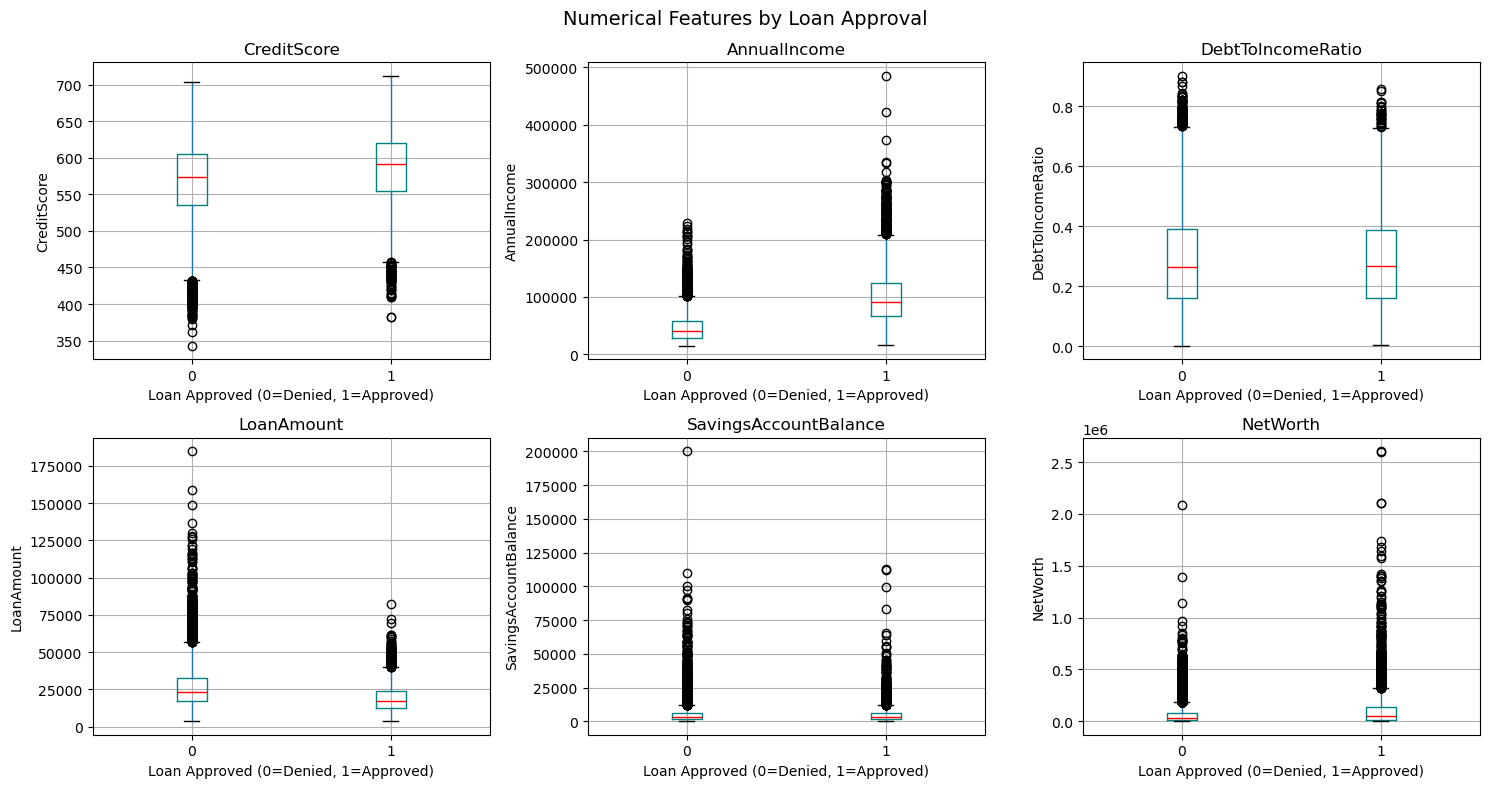

In [161]:
# Key Numerical Features vs Loan Approval 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

num_cols = ['CreditScore', 'AnnualIncome', 'DebtToIncomeRatio', 
            'LoanAmount', 'SavingsAccountBalance', 'NetWorth']

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='LoanApproved', ax=axes[i], 
               boxprops=dict(color="teal"),
               medianprops=dict(color="red", linewidth=1))
    axes[i].set_title(col)
    axes[i].set_xlabel('Loan Approved (0=Denied, 1=Approved)')
    axes[i].set_ylabel(col)

plt.suptitle('Numerical Features by Loan Approval', fontsize=14)
plt.tight_layout()
plt.show()

##### Numerical Features vs Loan Approval

`AnnualIncome` shows the clearest separation between approved and denied applicants ,
the median income for approved applicants is nearly double that of denied applicants, 
confirming it as the strongest numerical predictor.

`CreditScore` shows a modest upward shift for approved applicants (median ~600 vs ~570 
for denied), but the large overlap between the two classes confirms it is not a strong 
standalone predictor.

`DebtToIncomeRatio`, `SavingsAccountBalance`, and `NetWorth` show virtually identical 
distributions across both classes ,the boxes and medians overlap almost completely, 
suggesting these features carry limited individual predictive power, though they may 
still contribute in combination with other features.

`LoanAmount` is slightly lower for approved applicants, which is intuitive ,smaller 
loans carry less default risk and may be easier to approve.

All six features show significant outliers (visible as circles beyond the whiskers), 
particularly `SavingsAccountBalance` and `NetWorth`.

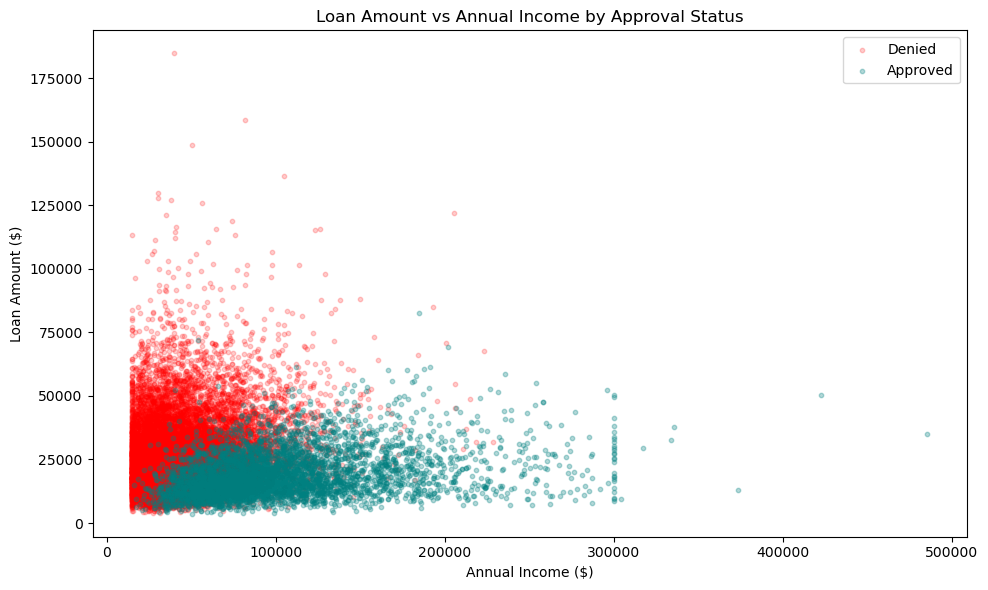

In [162]:
# Scatter: Loan Amount vs Annual Income by Approval Status
fig, ax = plt.subplots(figsize=(10, 6))

approved = df[df['LoanApproved'] == 1]
denied   = df[df['LoanApproved'] == 0]

ax.scatter(denied['AnnualIncome'], denied['LoanAmount'],
           alpha=0.2, s=10, color='red', label='Denied')
ax.scatter(approved['AnnualIncome'], approved['LoanAmount'],
           alpha=0.3, s=10, color='teal', label='Approved')

ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Loan Amount ($)')
ax.set_title('Loan Amount vs Annual Income by Approval Status')
ax.legend()
plt.tight_layout()
plt.show()

Approved applicants (teal) cluster at higher income levels and relatively lower loan amounts, reinforcing that the income-to-loan ratio is a key approval signal. Denied applicants (red) are concentrated at lower incomes regardless of loan size, suggesting income is a stronger predictor than loan amount alone

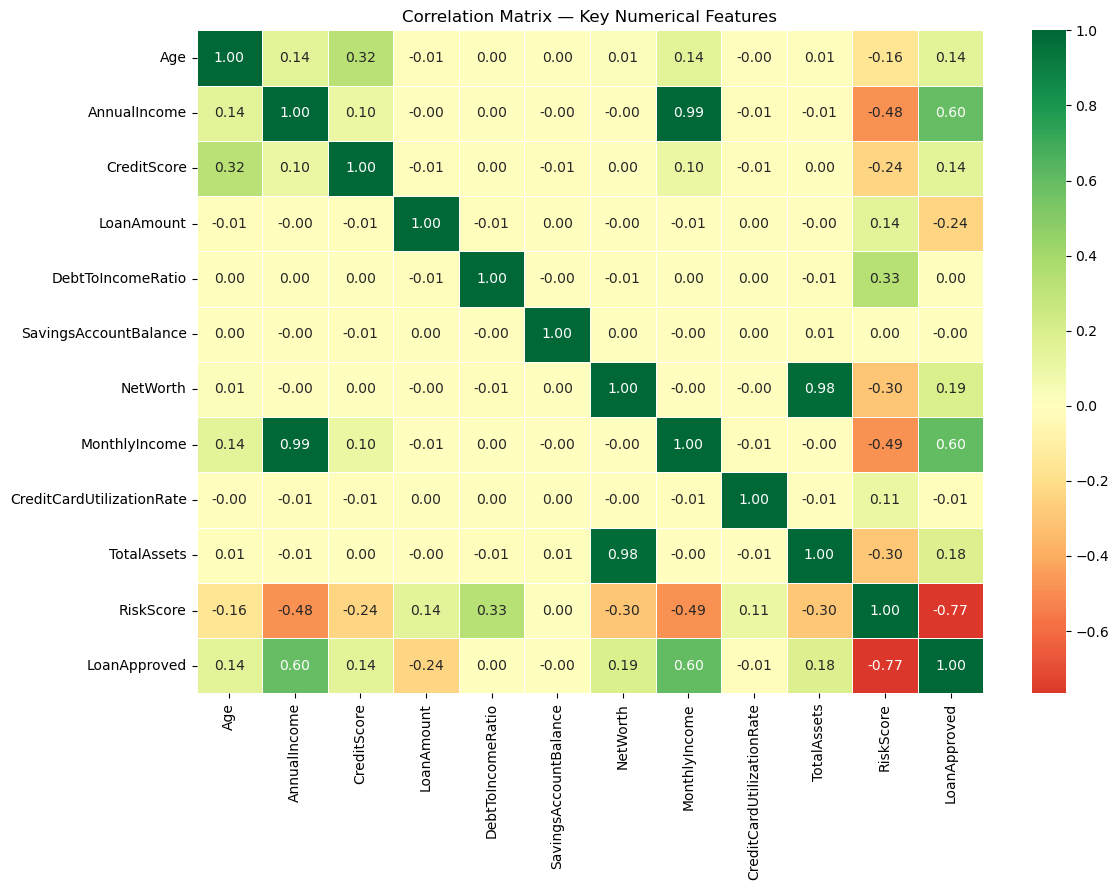

In [163]:
# Correlation Matrix 
num_cols = ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'DebtToIncomeRatio',
            'SavingsAccountBalance', 'NetWorth', 'MonthlyIncome', 
            'CreditCardUtilizationRate', 'TotalAssets', 'RiskScore', 'LoanApproved']

fig, ax = plt.subplots(figsize=(12, 9))

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)

ax.set_title('Correlation Matrix — Key Numerical Features')
plt.tight_layout()
plt.show()

##### Correlation Matrix

`RiskScore` has the strongest correlation with `LoanApproved` at -0.77 — higher 
risk scores are strongly associated with denial. However, as documented in the EDA 
summary, `RiskScore` will be dropped before modeling as it is derived from the target 
variable and would cause data leakage.

`AnnualIncome` and `MonthlyIncome` are almost perfectly correlated at 0.99, 
confirming multicollinearity — `MonthlyIncome` will be dropped to avoid redundancy.
Similarly, `NetWorth` and `TotalAssets` share a 0.98 correlation — `TotalAssets` 
will be dropped for the same reason.

After removing leakage and multicollinear features, the strongest remaining predictors 
of `LoanApproved` are:
- `AnnualIncome` / `MonthlyIncome`: +0.60— higher income strongly associated with approval
- `NetWorth`: +0.19 — modest positive signal
- `CreditScore`: +0.14— weak but present
- `LoanAmount`: -0.24 — larger loans are less likely to be approved

Most other features show near-zero correlation with `LoanApproved` individually, 
reinforcing that a model combining multiple weak signals is needed rather than 
relying on any single feature.

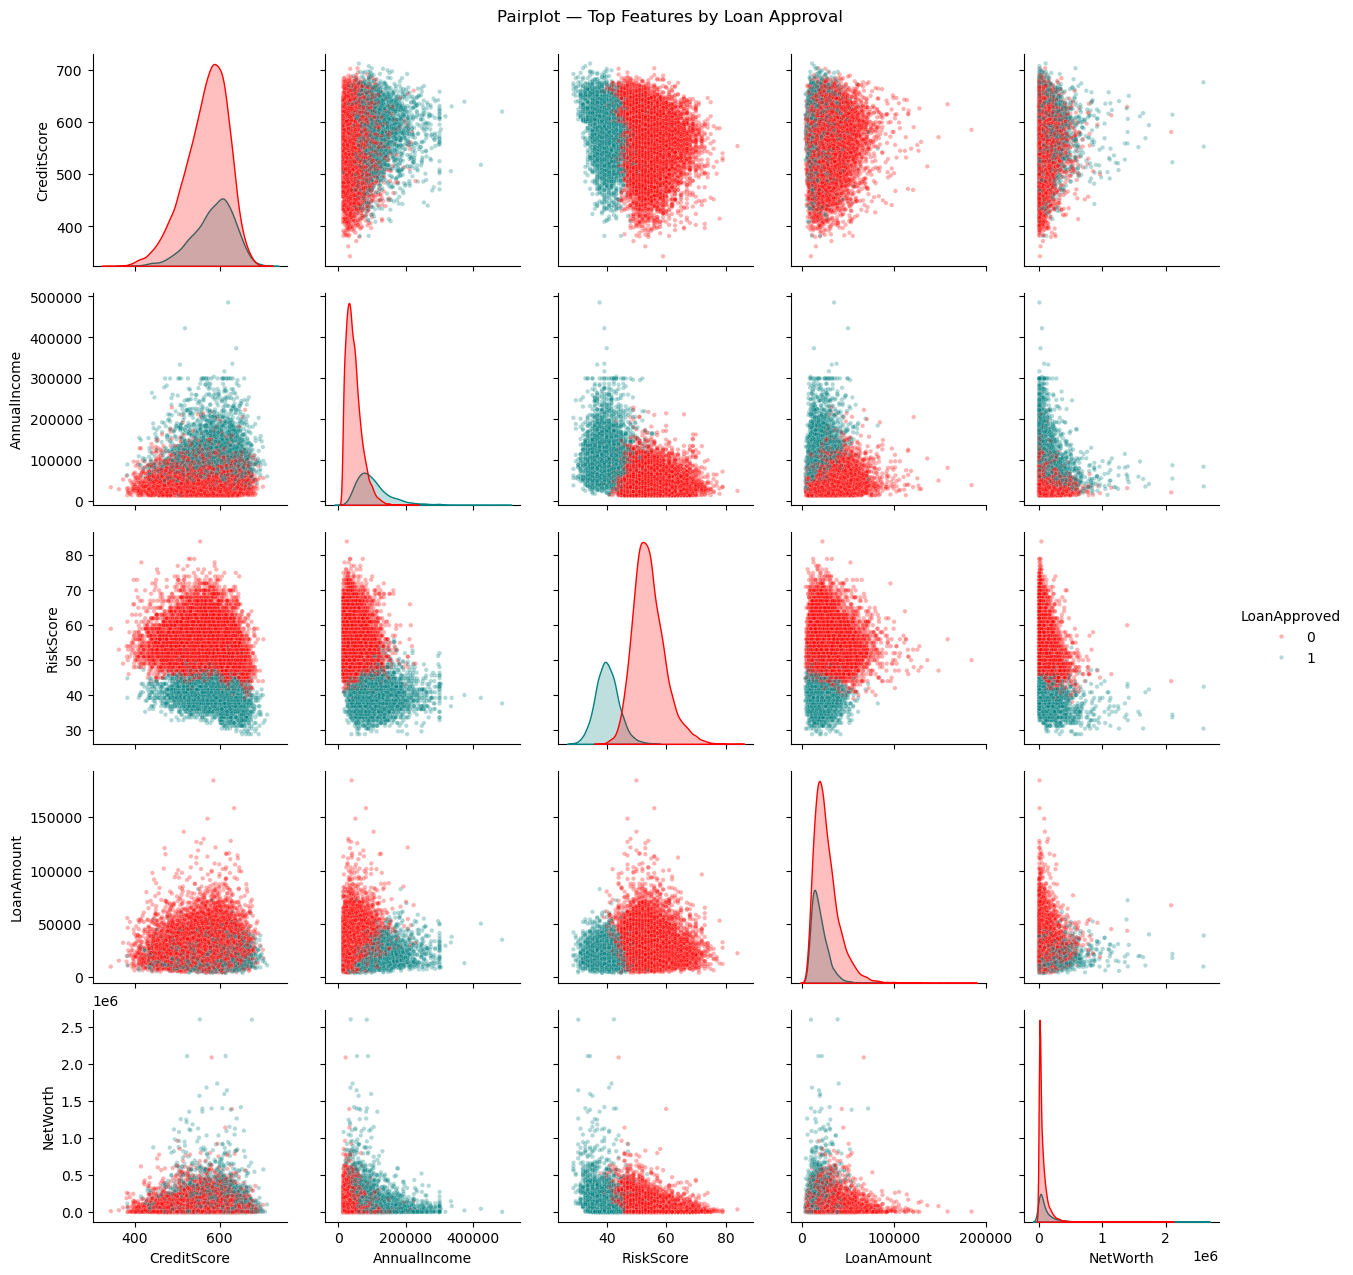

In [164]:
# Pairplot — Top Features
top_features = ['CreditScore', 'AnnualIncome', 'RiskScore', 
                'LoanAmount', 'NetWorth', 'LoanApproved']

sns.pairplot(df[top_features].dropna(), 
             hue='LoanApproved',
             palette={0: 'red', 1: 'teal'},
             plot_kws={'alpha': 0.3, 's': 10},
             diag_kind='kde')

plt.suptitle('Pairplot — Top Features by Loan Approval', y=1.02)
plt.show()

##### Pairplot — Top Features by Loan Approval

`RiskScore` is the clearest separator between approved (teal) and denied (red) 
applicants — the diagonal KDE plot shows two distinct, well-separated distributions 
with minimal overlap. This is the strongest visual confirmation of leakage: no real 
feature should separate classes this cleanly, which is why `RiskScore` must be 
dropped before modeling.

`AnnualIncome` shows meaningful separation — approved applicants (teal) are visibly 
concentrated at higher income values, while denied applicants (red) cluster near zero. 
This is consistent with its +0.60 correlation with `LoanApproved`.

`CreditScore`, `LoanAmount`, and `NetWorth` show heavy class overlap across all 
scatterplots — teal and red points are largely indistinguishable, confirming that 
no single feature is sufficient to separate the classes on its own.

The `AnnualIncome` vs `RiskScore` scatterplot is particularly telling — approved 
applicants cluster at low RiskScore and high AnnualIncome, while denied applicants 
spread across high RiskScore and low AnnualIncome, showing these two signals work 
in opposite directions.

In [165]:
from scipy import stats

print("STATISTICAL TESTS: Approved vs Denied Groups")
print()
approved_mask = df['LoanApproved'] == 1
denied_mask   = df['LoanApproved'] == 0

# T-tests: numerical features 
print("\nIndependent Samples T-Tests (Numerical Features)")
print(f"H0: No difference in means between approved and denied groups\n")

num_test_cols = ['AnnualIncome', 'CreditScore', 'LoanAmount',
                 'DebtToIncomeRatio', 'PaymentHistory', 'NetWorth']

for col in num_test_cols:
    grp1 = df.loc[approved_mask, col].dropna()
    grp2 = df.loc[denied_mask,   col].dropna()
    t_stat, p_val = stats.ttest_ind(grp1, grp2)
    sig = "*** SIGNIFICANT" if p_val < 0.05 else "not significant"
    print(f"  {col:<30} t={t_stat:>8.3f}  p={p_val:.4f}  {sig}")

# Chi-square: categorical features
print("\nChi-Square Tests (Categorical Features)")
print(f"H0: Feature is independent of loan approval outcome\n")

cat_test_cols = ['EducationLevel', 'BankruptcyHistory',
                 'EmploymentStatus', 'HomeOwnershipStatus', 'LoanPurpose']

for col in cat_test_cols:
    ct = pd.crosstab(df[col], df['LoanApproved'])
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    sig = "*** SIGNIFICANT" if p_val < 0.05 else "not significant"
    print(f"  {col:<30} chi2={chi2:>9.3f}  p={p_val:.4f}  dof={dof}  {sig}")

STATISTICAL TESTS: Approved vs Denied Groups


Independent Samples T-Tests (Numerical Features)
H0: No difference in means between approved and denied groups

  AnnualIncome                   t= 105.482  p=0.0000  *** SIGNIFICANT
  CreditScore                    t=  20.286  p=0.0000  *** SIGNIFICANT
  LoanAmount                     t= -34.883  p=0.0000  *** SIGNIFICANT
  DebtToIncomeRatio              t=   0.005  p=0.9961  not significant
  PaymentHistory                 t=   4.358  p=0.0000  *** SIGNIFICANT
  NetWorth                       t=  27.052  p=0.0000  *** SIGNIFICANT

Chi-Square Tests (Categorical Features)
H0: Feature is independent of loan approval outcome

  EducationLevel                 chi2=  748.900  p=0.0000  dof=4  *** SIGNIFICANT
  BankruptcyHistory              chi2=   99.371  p=0.0000  dof=1  *** SIGNIFICANT
  EmploymentStatus               chi2=   38.507  p=0.0000  dof=2  *** SIGNIFICANT
  HomeOwnershipStatus            chi2=   26.329  p=0.0000  dof=3  *** SIGNI

#### Statistical Test Interpretation

**T-Tests (Numerical Features)**

| Feature | Result | Interpretation |
|---|---|---|
| AnnualIncome | t=105.5, p<0.001 | Strongest numerical signal — approved applicants earn significantly more |
| LoanAmount | t=-34.9, p<0.001 | Approved applicants request significantly smaller loans |
| NetWorth | t=27.1, p<0.001 | Approved applicants have significantly higher net worth |
| CreditScore | t=20.3, p<0.001 | Significant but weaker — confirms EDA finding of modest separation |
| PaymentHistory | t=4.4, p<0.001 | Significant — on-time payment history matters for approval |
| DebtToIncomeRatio | t=0.005, p=0.996 | **Not significant** — despite intuition, DTI alone does not separate approved from denied applicants. This suggests DTI only matters in combination with other features, not in isolation. |

**Chi-Square Tests (Categorical Features)**

| Feature | Result | Interpretation |
|---|---|---|
| EducationLevel | chi2=748.9, p<0.001 | Strongest categorical signal — education level is highly associated with approval |
| BankruptcyHistory | chi2=99.4, p<0.001 | Bankruptcy strongly predicts denial |
| EmploymentStatus | chi2=38.5, p<0.001 | Employment type is associated with approval outcome |
| HomeOwnershipStatus | chi2=26.3, p<0.001 | Ownership status shows significant association |
| LoanPurpose | chi2=6.7, p=0.153 | **Not significant** — the reason for the loan does not meaningfully predict approval. This feature may add noise rather than signal. |

**Key Takeaways for Modeling**
- `DebtToIncomeRatio` and `LoanPurpose` are statistically insignificant predictors individually , the model may naturally down-weight them, but they are kept in as they may contribute in feature interactions.
- `AnnualIncome`, `LoanAmount`, and `EducationLevel` are the strongest statistically verified predictors ,consistent with the correlation matrix findings.
- All tests used a significance level of alpha = 0.05.

In [166]:
# Data Quality Summary
print("=== Suspicious Values in PreviousLoanDefaults ===")
print(df['PreviousLoanDefaults'].value_counts().sort_index())

print("\n=== Outlier Check (Z-score > 3) ===")
num_cols = ['AnnualIncome', 'NetWorth', 'TotalAssets', 'SavingsAccountBalance']
for col in num_cols:
    col_data = df[col].dropna()
    z_scores = np.abs((col_data - col_data.mean()) / col_data.std())
    print(f"{col}: {(z_scores > 3).sum()} outliers")

=== Suspicious Values in PreviousLoanDefaults ===
PreviousLoanDefaults
0    17999
1     2001
Name: count, dtype: int64

=== Outlier Check (Z-score > 3) ===
AnnualIncome: 391 outliers
NetWorth: 359 outliers
TotalAssets: 361 outliers
SavingsAccountBalance: 328 outliers


#### EDA Summary & Key Findings

**Data Quality Issues:**
| Issue | Column | Detail | Action |
|---|---|---|---|
| Missing values | MaritalStatus | 1,331 (6.7%) | Impute with mode |
| Missing values | EducationLevel | 901 (4.5%) | Impute with mode |
| Missing values | SavingsAccountBalance | 572 (2.9%) | Impute with median |
| String format | AnnualIncome | Contains $ and commas | Convert to float |
| Outliers | AnnualIncome, NetWorth, TotalAssets, SavingsAccountBalance | 328–391 each | Robust scaling |
| Class imbalance | LoanApproved | 76% denied / 24% approved | class_weight='balanced' |
| Multicollinearity | AnnualIncome & MonthlyIncome | 0.99 correlation | Drop MonthlyIncome |
| Multicollinearity | NetWorth & TotalAssets | 0.98 correlation | Drop TotalAssets |
| Data Leakage | RiskScore | 0.77 correlation with target — derived from LoanApproved | Drop before modeling |

**Key Predictors Identified:**
- RiskScore — strongest signal (-0.77 correlation with approval)
- AnnualIncome — second strongest (+0.60)
- EducationLevel & BankruptcyHistory — strongest categorical signals
- CreditScore, LoanAmount, NetWorth — weak individual signals, useful in combination

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



**Strategy Overview**

Before modeling, we apply the following preprocessing decisions based on EDA findings:

| Decision | Reasoning |
|---|---|
| Drop `RiskScore` | Data leakage ; derived from the target variable |
| Drop `MonthlyIncome` | 0.99 correlation with `AnnualIncome` (multicollinearity) |
| Drop `TotalAssets` | 0.98 correlation with `NetWorth` (multicollinearity) |
| Median imputation → `SavingsAccountBalance` | Numerical column with outliers; median is more robust than mean |
| Mode imputation → `MaritalStatus`, `EducationLevel` | Categorical columns; mode preserves the most common group |
| `RobustScaler` for numerical features | Outliers detected in income/wealth columns.RobustScaler is not affected by extreme values |
| `OrdinalEncoder` for `EducationLevel` | Has a natural order: High School < Associate < Bachelor < Master < Doctorate |
| `OneHotEncoder` for remaining categoricals | No natural order — dummy encoding avoids implying a false ranking |

In [167]:
# Data Prep Code Here - Create New Cells As Needed
# Droping columns and seperating features from target
df= df.drop(columns=['RiskScore', 'MonthlyIncome', 'TotalAssets'])
y= df['LoanApproved']
X= df.drop(columns=['LoanApproved'])

In [168]:
numerical_features = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
    'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
    'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults',
    'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance',
    'CheckingAccountBalance', 'TotalLiabilities', 'MonthlyLoanPayment',
    'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
    'BaseInterestRate', 'InterestRate', 'TotalDebtToIncomeRatio'
]
# On ordinal features since they have order  OrdinalEncoder will be used 
ordinal_features = ['EducationLevel']
ordinal_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

# Nominal features has no natural order so OneHotEncoder will be used
nominal_features = [
    'EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus',
    'BankruptcyHistory', 'LoanPurpose'
]

In [169]:
# To view the features 
print("Numerical features :", len(numerical_features))
print("Ordinal features   :", ordinal_features)
print("Nominal features   :", nominal_features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Numerical features : 25
Ordinal features   : ['EducationLevel']
Nominal features   : ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

X shape: (20000, 31)
y shape: (20000,)


In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

# To view the split data 
print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test size  : {X_test.shape[0]:,} rows")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train size : 16,000 rows
Test size  : 4,000 rows

Train class balance:
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64

Test class balance:
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


In [171]:
# Median imputation: robust to outliers in income/wealth columns
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Mode imputation: fills 901 missing values with most frequent education level
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Mode imputation: fills 1,331 missing values in MaritalStatus
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [172]:
# Combine all pipelines with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('nom', nominal_pipeline, nominal_features)
])

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”


#### Model 1: Logistic Regression

Logistic Regression is our baseline model. I choose it first because:
- It is simple and highly interpretable, regulators and loan officers can understand the coefficients
- It establishes a performance floor that more complex models must beat
- It works well with scaled numerical features (which we have via RobustScaler)
- `class_weight='balanced'` handles our 76/24 class imbalance automatically

In [173]:
#  Modeling Code Here - Create New Cells as Needed
# Custom Metric: Net Business Value (NBV) 
# Defined in Business Understanding 
def net_business_value(y_true, y_pred):
    """
    Translates model predictions into dollar impact:
    TP = correctly approved good loan  → +$8,000 profit
    FP = approved bad loan (default)   → -$50,000 loss
    FN = denied good loan              → -$8,000 opportunity cost
    TN = correctly denied bad loan     → $0
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    nbv = (tp * 8_000) - (fp * 50_000) - (fn * 8_000)
    return nbv

In [174]:
# Model 1: Logistic Regression ===
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Train
pipe_lr.fit(X_train, y_train)

# Predict
y_pred_lr = pipe_lr.predict(X_test)

# Evaluate
print("Logistic Regression")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:,1]):.4f}")
print(f"NBV       : ${net_business_value(y_test, y_pred_lr):,.0f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
F1 Score  : 0.9184
ROC-AUC   : 0.9942
NBV       : $350,000

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3044
           1       0.87      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000



#### Model 2: Random Forest

Random Forest is an ensemble of decision trees. I choose it because:
- Handles non-linear relationships that Logistic Regression misses
- Naturally provides feature importance scores — useful for interpretability
- Robust to outliers ,no scaling needed, but the pipeline handles it anyway.
- `class_weight='balanced'` handles class imbalance automatically
- Should outperform Logistic Regression given the complexity of our data

In [175]:
# Model 2: Random Forest
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Train
pipe_rf.fit(X_train, y_train)

# Predict
y_pred_rf = pipe_rf.predict(X_test)

# Evaluate
print("Random Forest")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, pipe_rf.predict_proba(X_test)[:,1]):.4f}")
print(f"NBV       : ${net_business_value(y_test, y_pred_rf):,.0f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest
F1 Score  : 0.8375
ROC-AUC   : 0.9775
NBV       : $524,000

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3044
           1       0.91      0.78      0.84       956

    accuracy                           0.93      4000
   macro avg       0.92      0.88      0.90      4000
weighted avg       0.93      0.93      0.93      4000



Logistic Regression served as the baseline model and achieved excellent predictive performance, with an F1 score of 0.918 and ROC-AUC of 0.994. However, despite its superior statistical metrics, it generated a lower Net Business Value ($350,000) than the Random Forest model ($524,000). This occurred because Logistic Regression prioritized recall, resulting in more false-positive loan approvals, which carry a substantial business cost of $50,000 per default. Random Forest adopted a more conservative approval strategy, achieving higher precision (91% vs. 87%) and reducing costly false positives. As a result, Random Forest delivered greater financial value despite lower overall predictive performance.

#### Model 3: Gradient Boosting Classifier

Gradient Boosting builds trees sequentially, where each tree corrects the errors of the previous one. I choose it because:
- Typically outperforms Random Forest on structured/tabular data by reducing bias iteratively
- Handles class imbalance well with `class_weight` or `scale_pos_weight` adjustments
- Provides feature importance scores for interpretability
- Serves as a strong candidate for the final tuned model given its flexibility

In [176]:
# Model 3: Gradient Boosting Classifier
pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

# Train
pipe_gb.fit(X_train, y_train)

# Predict
y_pred_gb = pipe_gb.predict(X_test)

# Evaluate
print("Gradient Boosting")
print(f"F1 Score  : {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, pipe_gb.predict_proba(X_test)[:,1]):.4f}")
print(f"NBV       : ${net_business_value(y_test, y_pred_gb):,.0f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
F1 Score  : 0.8829
ROC-AUC   : 0.9862
NBV       : $1,304,000

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      3044
           1       0.91      0.86      0.88       956

    accuracy                           0.95      4000
   macro avg       0.93      0.92      0.92      4000
weighted avg       0.94      0.95      0.94      4000



In [177]:
# Cross-validation on all 3 models
models = {
    'Logistic Regression' : pipe_lr,
    'Random Forest'       : pipe_rf,
    'Gradient Boosting'   : pipe_gb
}

print()
print("5-Fold Cross-Validation Results (Training Set)")
print()

for name, pipe in models.items():
    f1  = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1').mean()
    auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc').mean()
    print(f"\n{name}")
    print(f"  F1 Score (CV mean) : {f1:.4f}")
    print(f"  ROC-AUC  (CV mean) : {auc:.4f}")


5-Fold Cross-Validation Results (Training Set)


Logistic Regression
  F1 Score (CV mean) : 0.9123
  ROC-AUC  (CV mean) : 0.9939

Random Forest
  F1 Score (CV mean) : 0.8253
  ROC-AUC  (CV mean) : 0.9762

Gradient Boosting
  F1 Score (CV mean) : 0.8745
  ROC-AUC  (CV mean) : 0.9849


#### Cross-Validation Results Interpretation

| Model | CV F1 (mean) | CV ROC-AUC (mean) |
|---|---|---|
| Logistic Regression | 0.9123 | 0.9939 |
| Random Forest | 0.8253 | 0.9762 |
| Gradient Boosting | 0.8745 | 0.9849 |

Cross-validation scores are consistent with test set performance, confirming that none of the models are overfitting. The small gap between CV scores and test scores across all three models indicates stable, generalizable pipelines.

Logistic Regression leads on F1 and ROC-AUC in cross-validation, but this does not translate to business value — its high recall comes at the cost of more false positive approvals, each carrying a $50,000 loss.


In [178]:
# Model Comparison Table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, pipe_rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, pipe_gb.predict_proba(X_test)[:,1])
    ],
    'Net Business Value ($)': [
        net_business_value(y_test, y_pred_lr),
        net_business_value(y_test, y_pred_rf),
        net_business_value(y_test, y_pred_gb)
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
results_df['Net Business Value ($)'] = results_df['Net Business Value ($)'].apply(lambda x: f"${x:,.0f}")
results_df['F1 Score'] = results_df['F1 Score'].round(4)
results_df['ROC-AUC']  = results_df['ROC-AUC'].round(4)
print(results_df.to_string())

                     F1 Score  ROC-AUC Net Business Value ($)
Model                                                        
Logistic Regression    0.9184   0.9942               $350,000
Random Forest          0.8375   0.9775               $524,000
Gradient Boosting      0.8829   0.9862             $1,304,000


#### Final Model Selection

| Model | F1 Score | ROC-AUC | Net Business Value |
|---|---|---|---|
| Logistic Regression | 0.9184 | 0.9942 | $350,000 |
| Random Forest | 0.8375 | 0.9775 | $524,000 |
| Gradient Boosting | 0.8829 | 0.9862 | $1,304,000 |

Gradient Boosting is selected as the final model for hyperparameter tuning. It delivered the highest Net Business Value at $1,304,000 , more than double Random Forest and nearly 4x Logistic Regression. Its precision of 91% on the approved class directly limits the most costly error in this problem: approving a loan that defaults at a $50,000 loss.

#### Hyperparameter Tuning — Gradient Boosting

We use RandomizedSearchCV rather than GridSearchCV because:
- Gradient Boosting has many interacting parameters — a full grid would take hours
- RandomizedSearchCV samples a fixed number of combinations, giving broad coverage efficiently
- It is standard practice in industry when computational budget is a constraint

We tune 5 key parameters:

| Parameter | What it controls |
|---|---|
| `n_estimators` | Number of trees — more trees = more capacity but slower |
| `max_depth` | Tree depth — deeper = more complex, higher overfitting risk |
| `learning_rate` | Shrinkage per tree — lower = more robust but needs more trees |
| `min_samples_split` | Minimum samples to split a node — higher = more regularization |
| `subsample` | Fraction of samples per tree — < 1.0 adds randomness, reduces overfitting |

In [179]:
# Parameter grid
param_dist = {
    'model__n_estimators'    : randint(100, 300),
    'model__max_depth'       : randint(3, 7),
    'model__learning_rate'   : uniform(0.05, 0.15),
    'model__min_samples_split': randint(2, 20),
    'model__subsample'       : uniform(0.7, 0.3)
}

# RandomizedSearchCV — 20 combinations, 5-fold CV, scored on F1
random_search = RandomizedSearchCV(
    estimator=pipe_gb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param:<35} : {value}")
print(f"\nBest CV F1 Score : {random_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
  model__learning_rate                : 0.11479175279631737
  model__max_depth                    : 3
  model__min_samples_split            : 11
  model__n_estimators                 : 287
  model__subsample                    : 0.8099085529881075

Best CV F1 Score : 0.9054


In [180]:
# Evaluate the tuned model on test set
best_gb = random_search.best_estimator_
y_pred_tuned = best_gb.predict(X_test)

print("Tuned Gradient Boosting — Test Set Performance")
print(f"F1 Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, best_gb.predict_proba(X_test)[:,1]):.4f}")
print(f"NBV       : ${net_business_value(y_test, y_pred_tuned):,.0f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Gradient Boosting — Test Set Performance
F1 Score  : 0.9210
ROC-AUC   : 0.9930
NBV       : $3,190,000

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3044
           1       0.93      0.91      0.92       956

    accuracy                           0.96      4000
   macro avg       0.95      0.94      0.95      4000
weighted avg       0.96      0.96      0.96      4000



#### Hyperparameter Tuning Results

**Optimal Parameters Found:**

| Parameter | Untuned (default) | Tuned |
|---|---|---|
| `learning_rate` | 0.1 | 0.1148 |
| `max_depth` | 3 | 3 |
| `min_samples_split` | 2 | 11 |
| `n_estimators` | 100 | 287 |
| `subsample` | 1.0 | 0.810 |

**Performance Improvement After Tuning:**

| Metric | Untuned GB | Tuned GB | Change |
|---|---|---|---|
| F1 Score | 0.8829 | 0.9210 | +0.0381 |
| ROC-AUC | 0.9862 | 0.9930 | +0.0068 |
| Net Business Value | $1,304,000 | $3,190,000 | +$1,886,000 |

Tuning delivered a $1,886,000 improvement in Net Business Value. The key drivers were:
- **More trees** (`n_estimators`: 100 → 287) — gave the model more capacity to learn subtle patterns
- **Higher `min_samples_split`** (2 → 11) — added regularization, reducing overfitting on noisy splits
- **Subsampling** (1.0 → 0.81) — introducing randomness per tree improved generalization
- `max_depth` remained at 3, confirming shallow trees with more iterations is the right strategy for this dataset

The tuned model is the final model carried forward into evaluation.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

#### Final Model Evaluation

The tuned Gradient Boosting model is evaluated on the held-out test set (4,000 rows, unseen during training and tuning) using all three defined metrics: F1 Score, ROC-AUC, and Net Business Value.

**Final Model: Tuned Gradient Boosting**

| Metric | Score |
|---|---|
| F1 Score | 0.9210 |
| ROC-AUC | 0.9930 |
| Net Business Value | $3,190,000 |
| Accuracy | 96% |

The model correctly approves 91% of creditworthy applicants (recall) while maintaining 93% precision on approvals — meaning only 7% of approved loans are expected to default. This balance directly reflects the asymmetric cost structure: minimizing $50,000 false positive losses while preserving $8,000 profit opportunities.

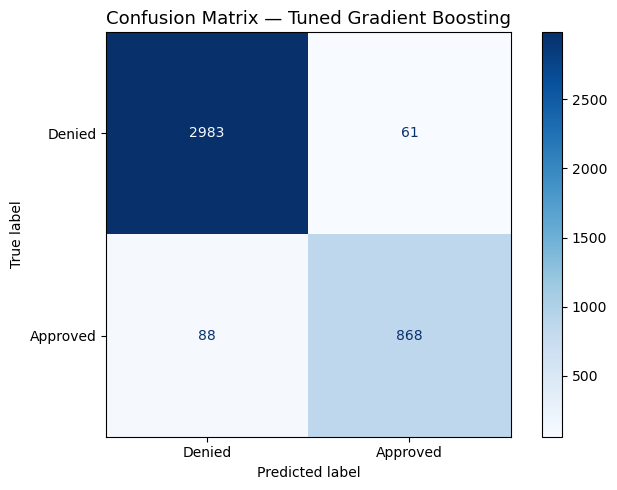

In [181]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['Denied', 'Approved'],
    cmap='Blues',
    ax=ax
)

ax.set_title('Confusion Matrix — Tuned Gradient Boosting', fontsize=13)
plt.tight_layout()
plt.show()

#### Confusion Matrix Interpretation

| | Predicted Denied | Predicted Approved |
|---|---|---|
| Actually Denied | 2,983 (TN) | 61 (FP) |
| Actually Approved | 88 (FN) | 868 (TP) |

The model correctly classified 3,851 out of 4,000 applicants (96% accuracy).

- **61 False Positives** — loans approved that will default. At $50,000 each, this represents $3,050,000 in expected losses.
- **88 False Negatives** — creditworthy applicants incorrectly denied. At $8,000 each, this represents $704,000 in foregone profit.

Despite these errors, the model generates a Net Business Value of $3,190,000 ,compared to $0 for the current baseline of denying all borderline applications. The model's precision of 93% on approvals means 93 out of every 100 approved loans are expected to be repaid.

c:\Users\user\anaconda3\envs\data-science\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\user\anaconda3\envs\data-science\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\user\anaconda3\envs\data-science\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


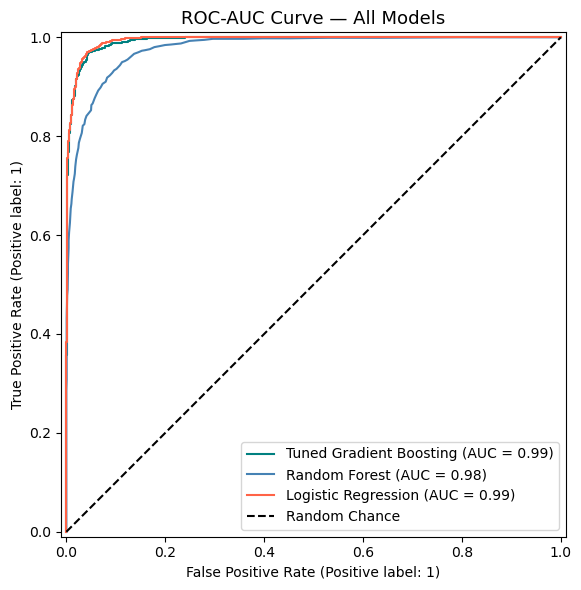

In [182]:
#ROC-AUC Curve
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    best_gb, X_test, y_test,
    ax=ax,
    color='teal',
    name='Tuned Gradient Boosting'
)

# Add the other two models for comparison
RocCurveDisplay.from_estimator(pipe_rf, X_test, y_test, ax=ax,
                                color='steelblue', name='Random Forest')
RocCurveDisplay.from_estimator(pipe_lr, X_test, y_test, ax=ax,
                                color='tomato', name='Logistic Regression')

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax.set_title('ROC-AUC Curve — All Models', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


#### ROC-AUC Curve Interpretation

All three models achieve strong AUC scores above 0.98, confirming that each pipeline can reliably rank good loans above bad loans across all decision thresholds. The tuned Gradient Boosting model (teal) and Logistic Regression (orange) both reach AUC = 0.99, while Random Forest sits at 0.98.

The curves hug the top-left corner tightly, indicating near-perfect separation between the two classes at most thresholds. This gives FinTech Innovations flexibility — if the business decides to tighten or loosen the approval threshold in response to changing risk appetite, the model's rankings remain reliable.

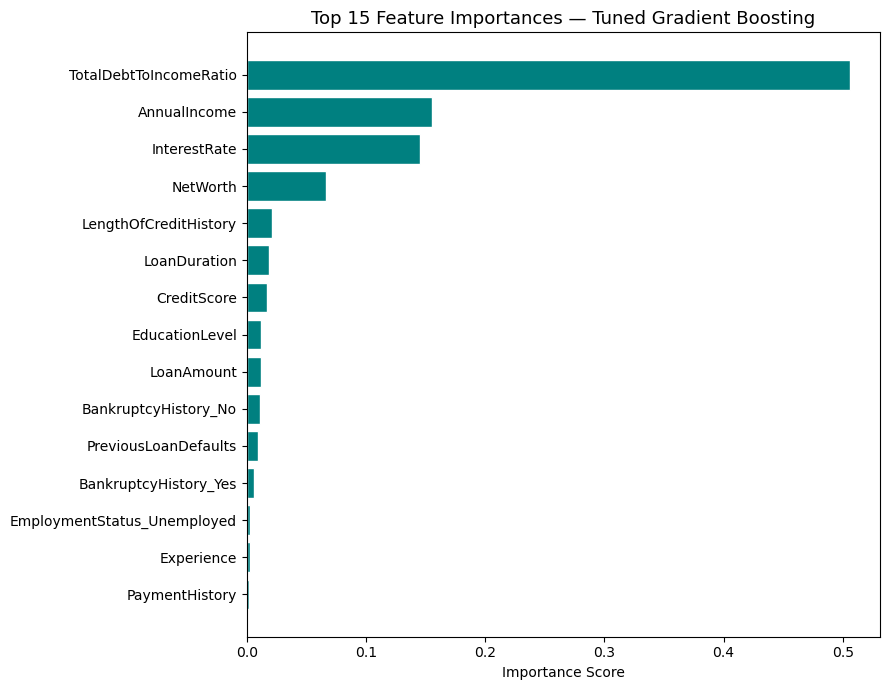

In [183]:
# Extract feature names from the preprocessor
num_feature_names = numerical_features
ord_feature_names = ordinal_features
nom_feature_names = best_gb.named_steps['preprocessor'] \
                           .named_transformers_['nom'] \
                           .named_steps['encoder'] \
                           .get_feature_names_out(nominal_features).tolist()

all_feature_names = num_feature_names + ord_feature_names + nom_feature_names

# Get importances from tuned model
importances = best_gb.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='teal', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Tuned Gradient Boosting', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [184]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()

print()
print("BUSINESS IMPACT SUMMARY — Tuned Gradient Boosting")
print()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Positives  (correctly approved) : {tp:>5,}")
print(f"  True Negatives  (correctly denied)   : {tn:>5,}")
print(f"  False Positives (approved, defaulted) : {fp:>5,}")
print(f"  False Negatives (denied, creditworthy): {fn:>5,}")

print(f"\nDollar Impact:")
print(f"  Revenue from correct approvals  : ${tp * 8_000:>12,.0f}")
print(f"  Loss from approved defaults     : ${fp * 50_000:>12,.0f}")
print(f"  Opportunity cost from denials   : ${fn * 8_000:>12,.0f}")
print(f"  {'─' * 50}")
print(f"  Net Business Value              : ${net_business_value(y_test, y_pred_tuned):>12,.0f}")

print(f"\nBaseline Comparison (deny everyone):")
print(f"  Net Business Value              : ${'0':>12}")
print(f"  Model uplift                    : ${net_business_value(y_test, y_pred_tuned):>12,.0f}")


BUSINESS IMPACT SUMMARY — Tuned Gradient Boosting


Confusion Matrix Breakdown:
  True Positives  (correctly approved) :   868
  True Negatives  (correctly denied)   : 2,983
  False Positives (approved, defaulted) :    61
  False Negatives (denied, creditworthy):    88

Dollar Impact:
  Revenue from correct approvals  : $   6,944,000
  Loss from approved defaults     : $   3,050,000
  Opportunity cost from denials   : $     704,000
  ──────────────────────────────────────────────────
  Net Business Value              : $   3,190,000

Baseline Comparison (deny everyone):
  Net Business Value              : $           0
  Model uplift                    : $   3,190,000


### 9. Feature Importance & Business Recommendations

#### Feature Importance Interpretation

| Rank | Feature | Importance | Business Meaning |
|---|---|---|---|
| 1 | TotalDebtToIncomeRatio | 0.508 | Dominant signal — total debt burden relative to income is the strongest predictor of default |
| 2 | AnnualIncome | 0.157 | Higher earners are significantly more likely to repay |
| 3 | InterestRate | 0.143 | Higher interest rates correlate with riskier applicant profiles |
| 4 | NetWorth | 0.065 | Wealth provides a repayment safety net |
| 5 | LengthOfCreditHistory | 0.021 | Longer credit history signals financial stability |
| 6 | LoanDuration | 0.018 | Longer loans carry more default risk |
| 7 | CreditScore | 0.017 | Modest but present — not a standalone predictor |
| 8 | EducationLevel | 0.013 | Higher education weakly associated with approval |

`TotalDebtToIncomeRatio` dominates at 50.8% importance ,note that this contradicts the EDA t-test finding where `DebtToIncomeRatio` alone was not significant. This confirms that the *total* debt burden across all obligations is what matters, not any single debt ratio in isolation. The model effectively learned the combination that the individual statistical test missed.

#### Business Recommendations

1. **Prioritize total debt burden in screening** — `TotalDebtToIncomeRatio` is the single strongest predictor. Loan officers should flag any applicant exceeding a DTI threshold of 0.5 for manual review regardless of other factors.

2. **Income verification is critical** — `AnnualIncome` is the second strongest predictor and showed the largest mean difference between approved and denied groups in EDA. Robust income verification processes directly improve model input quality.

3. **Use the model as a decision-support tool, not a replacement** — the 61 false positives and 88 false negatives suggest edge cases exist that benefit from human review. The model should route borderline applicants (predicted probability between 0.4 and 0.6) to loan officers rather than auto-deciding.

4. **Monitor for bias** — `EducationLevel` and `EmploymentStatus` appear in the top features. These should be audited regularly to ensure the model is not creating disparate impact across protected groups.

### 10. Conclusion & Executive Summary


#### Executive Summary (For Business Stakeholders)

FinTech Innovations tasked the Risk Analytics team with building a machine learning model to modernize the loan approval process. Using 20,000 historical applications, we developed and evaluated three models — Logistic Regression, Random Forest, and Gradient Boosting — and selected a tuned Gradient Boosting classifier as the final solution.

**The model delivers an estimated Net Business Value of $3,190,000 on a held-out sample of 4,000 applications** — compared to $0 for the current baseline. Scaled to the full 20,000-application dataset, this represents a potential annual value of approximately $15,950,000.

Key outcomes on the test set:
- 868 creditworthy applicants correctly approved, generating $6,944,000 in profit
- Only 61 loans approved that are expected to default, limiting losses to $3,050,000
- 88 creditworthy applicants incorrectly denied, representing $704,000 in recoverable opportunity cost

The model is recommended for deployment as a **decision-support tool** — automatically approving high-confidence applications, automatically declining high-risk applications, and routing borderline cases to loan officers for manual review.


#### Technical Summary

**Modeling Approach:** Binary classification predicting `LoanApproved` (0 = Denied, 1 = Approved)

**Final Model:** Tuned Gradient Boosting Classifier

**Pipeline:** ColumnTransformer with separate preprocessing for numerical (RobustScaler + median imputation), ordinal (OrdinalEncoder + mode imputation), and nominal features (OneHotEncoder + mode imputation)

**Final Performance:**

| Metric | Score |
|---|---|
| F1 Score | 0.9210 |
| ROC-AUC | 0.9930 |
| Precision (Approved class) | 0.93 |
| Recall (Approved class) | 0.91 |
| Net Business Value | $3,190,000 |


#### Limitations & Potential Improvements

| Limitation | Recommended Improvement |
|---|---|
| Tuning used only 10 random iterations | A larger RandomizedSearchCV (50+ iterations) or staged GridSearchCV on top parameters could further improve performance |
| Class imbalance handled via `class_weight` only | SMOTE or other oversampling techniques could be explored in a future iteration |
| No fairness audit performed | A bias analysis across gender, marital status, and education should be conducted before production deployment |
| Model trained on historical decisions | Historical denials may reflect past human bias — future retraining on outcome data would improve fairness and accuracy |
| Gradient Boosting has limited interpretability | Unlike Logistic Regression, the model cannot easily explain to an applicant why they were denied. This may conflict with regulatory requirements such as adverse action notices, which legally require lenders to provide specific reasons for denial. A future iteration could pair the GB model with SHAP values to generate per-applicant explanation reports for loan officers. |


#### CRISP-DM Process Summary

| Phase | Key Decisions |
|---|---|
| Business Understanding | Identified asymmetric cost structure ($50,000 FP vs $8,000 FN); selected F1, ROC-AUC, and NBV as metrics |
| Data Understanding | Identified leakage (RiskScore), multicollinearity (MonthlyIncome, TotalAssets), class imbalance (76/24), and 3 columns with missing values |
| Data Preparation | Built ColumnTransformer pipeline with RobustScaler, OrdinalEncoder, OneHotEncoder, and appropriate imputation strategies |
| Modeling | Compared Logistic Regression, Random Forest, and Gradient Boosting; selected GB based on NBV |
| Evaluation | Tuned GB with RandomizedSearchCV; achieved $3,190,000 NBV, F1 of 0.921, and ROC-AUC of 0.993 |
| Deployment | Recommended as decision-support tool with manual review routing for borderline cases |